# motor_unit_based_muscle_model

## Background/Description: 
The goal of this project is to simulate Henneman's Size Principle of motor unit recruitment. This principle describes the relation between motor neurons and muscle fibers which together form motor units. In order to contract a muscle, motor neurons with large cell bodies (large motor units) are connected to higher force output and stronger muscle fibers, while motor units connected to small cell bodies (small motor units) are related to weaker muscle fibers and are recruited earlier than their larger counterparts. Not only that, but there are very few large motor units, while there is a much larger number of smaller motor units. This creates a structured hierarchy in muscle activation where low-force control is prioritized before high-force output is reached. The main question I'm looking to answer is how the range of recruitment thresholds affects how "smooth" the force production is. As stated previously, in each muscle the amount of small motor units is much greater than the large motor units. As a result of this, the threshold to activate the smaller (e.g., the first and second) motor units is practically the same, and the difference in their maximum force output is almost negligible. This is what allows humans to make fine, precise movements such as eye tracking, writing, or maintaining posture. At low levels of neural drive, many motor units overlap in their activation ranges, which produces a smooth and continuous increase in force. On the other hand, when reaching the higher ends of the recruitment threshold range, there are much fewer large motor units, and the difference in the threshold required to activate them, as well as their force contributions, grows significantly. This means that instead of smooth transitions between motor units like we observe at low force levels, higher-force regions tend to produce larger, more discrete jumps in total force output. In the context of a real-life scenario, this corresponds to the small shakes and lack of stability one might feel when lifting heavy weight, where each newly recruited high-threshold motor unit produces a noticeable increase in force. However, this represents an idealized case based purely on recruitment order. In real biological systems, a second key factor influences the smoothness of force production: activation dynamics. This is described in the research by Liu et al. (2002), which models the muscle as a first-order system with a finite activation time constant. While the size principle determines which motor units are recruited, the biochemical processes within the muscle fibers determine how quickly they produce force after being activated. In a biological system like the human body, force output does not instantly jump to its maximum value when a motor unit is recruited. Instead, force increases over time as calcium ions are released and bind within the muscle fibers, initiating cross-bridge cycling. This introduces a delay between when the brain sends a signal and when the muscle produces mechanical force. In this project, I will explore how differences in recruitment threshold distributions of motor units affect the stability of force output, both with and without this biological activation lag. This is achieved by modeling the transition from neural drive to physical contraction using differential equations, allowing a comparison between instantaneous activation and time-dependent muscle dynamics.


## Methods 

The very first thing I needed to do was to import numpy and matplotlib below

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Then in order to simulate the muscle pool, I used an exponential function to define the properties of an n number of motor units, for both cases we use n=50. I then used the Fuglevand Model in order to represent the recruit thresholds recruitment thresholds (T) and maximum forces (F) were

The distribution follows these exponential forms:

$$T_i = e^{\ln(RR) \cdot (i/n)}$$

$$F_{i} = e^{\ln(FR) \cdot (i/n)}$$

* **RR (Recruitment Range):** The ratio of the highest threshold to the lowest.
* **FR (Force Range):** The ratio of the maximum force of the largest unit to the smallest.

In [3]:
# 1. Define the Muscle Pool
def create_muscle_pool(n_units, RR, FR):
    # Exponential distribution based on the Fuglevand Model
    thresholds = np.exp(np.log(RR) * np.linspace(0, 1, n_units))
    max_forces = np.exp(np.log(FR) * np.linspace(0, 1, n_units))
    return thresholds, max_forces

n_units = 50
RR = 30      # Recruitment Range (Henneman's Size Principle)
FR = 100     # Force Range (Max Force of the largest unit vs smallest)

#Definiing two muscle pools to compare the effect of recruitment range on force generation

#Pool 1
thresholds1, max_forces = create_muscle_pool(n_units, RR, FR) #First muscle pool with original RR and FR
#Pool 2
thresholds2, max_forces = create_muscle_pool(n_units, RR*2, FR) #Second muscle pool with doubled RR to see the effect on recruitment and force generation

print("Thresholds 1:", thresholds1)
print("Thresholds 2:", thresholds2)
print("Max Forces:", max_forces)


Thresholds 1: [ 1.          1.07187794  1.14892231  1.23150448  1.32002248  1.41490297
  1.51660328  1.62561359  1.74245934  1.86770373  2.00195042  2.14584648
  2.3000855   2.4654109   2.64261955  2.8325656   3.03616457  3.25439781
  3.48831721  3.73905026  4.00780548  4.29587827  4.60465714  4.93563039
  5.29039332  5.67065588  6.07825093  6.51514306  6.98343811  7.48539323
  8.02342785  8.6001353   9.21829528  9.88088733 10.59110513 11.35237191
 12.16835699 13.04299338 13.98049684 14.98538611 16.06250475 17.21704446
 18.45457009 19.78104652 21.20286734 22.7268857  24.36044736 26.11142606
 27.9882615  30.        ]
Thresholds 2: [ 1.          1.08714832  1.18189148  1.28489134  1.39686747  1.51860213
  1.65094576  1.79482292  1.95123873  2.12128592  2.30615243  2.50712976
  2.72562191  2.9631553   3.22138932  3.502128    3.80733259  4.13913525
  4.49985395  4.89200869  5.31833905  5.78182339  6.28569961  6.8334878
  7.42901482  8.07644102  8.78028932  9.54547683 10.37734915 11.2817177

Cell block [3] (above) defines our two muscle pools as well as the recruitment range and force range of the muscle. Then uses those values and the equation above that to define our thresholds and max forces as two arrays. 

To simulate a dynamic muscle contraction, the model requires a continuous input signal and a time domain. I defined a time step ($dt$) of 0.01 seconds (10ms). This value was chosen for the Euler Method. It's small enough to maintain stability in our differential equations while accurately representing the firing frequency limits of biological motor neurons. We set the total simulation time to 10 seconds to allow for multiple recruitment cycles. The code for this is shown below.

In [4]:
dt = 0.01  # 10ms time steps
time = np.arange(0, 10, dt)
# A sine wave representing a 10-second rhythmic contraction
neural_drive = 20 * np.sin(time * 0.6) + 20

The first method assumes an ideal muscle with an instant reaction speed. In this approach I caculate force instantly as a function of the Neural Drive ($u$). The activation of each unit is determined the following sigmoidal function: $$a_i = \frac{1}{1 + e^{-{k}{(u - T_i)}}}$$

We then define a function in the cell block below modeling the equation above. Aftwerward we call that function for both motor pools to get the static force for both.

In [5]:
# Model A: Static (No ODE)
def compute_force_static(neural_drive, thresholds, max_forces):
    force_static = []
    for drive in neural_drive:
        # Instant sigmoid activation based on Fuglevand logic
        target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
        force_static.append(np.sum(max_forces * target))
    return force_static

force_static1 = compute_force_static(neural_drive, thresholds1, max_forces)
force_static2 = compute_force_static(neural_drive, thresholds2, max_forces)

In this model, the force output has no memory of the previous time step; it is a direct "lookup" of the current brain signal.

Method 2: Dynamic Model (Liu et al. - With Biological Lag)The second method I used is a much more realistic model as we create a muscle which has a sort of biological lag that takes place between the brain signal and the muscle contraction. Following Liu et al. (2002), we assumed that force production is limited by a time constant ($\tau$). This requires us to solve the following first-order Ordinary Differential Equation (ODE):$$\frac{da}{dt} = \frac{Target - a_t}{\tau}$$We solve this numerically using the Euler Method, which updates the activation by adding the "nudge" calculated from the derivative to the previous state:$$a_{t+1} = a_t + \left( \frac{Target - a_t}{\tau} \right) \cdot dt$$

In [8]:
# Model B: Dynamic (Liu et al. ODE via Euler Method)
def compute_force_ode(neural_drive, thresholds, max_forces, dt):
    force_ode = []
    current_a = np.zeros(n_units)
    tau = 0.15 # The time constant for activation lag

    for drive in neural_drive:
        target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
        # ODE: da/dt = (target - current) / tau
        da_dt = (target - current_a) / tau
        current_a += da_dt * dt # The Euler Step
        force_ode.append(np.sum(max_forces * current_a))
    return force_ode

force_ode1 = compute_force_ode(neural_drive, thresholds1, max_forces, dt)
force_ode2 = compute_force_ode(neural_drive, thresholds2, max_forces, dt)

We can then define a function to graph both the static and dynamic force outputs for a single motor pool, along with the nueral drive using matplotlib below. 

In [ ]:

def plot_force_outputs(time, force_static, force_ode, neural_drive, title):
    # Create the main figure and the first axis (ax1)
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- LEFT Y-AXIS: FORCE ---
    color_static = '#1f77b4' # Muted Blue
    color_ode = '#ff7f0e'    # Muted Orange

    line1 = ax1.plot(time, force_static, label='Static Model (RR = 20)', color=color_static, linewidth=2)
    line2 = ax1.plot(time, force_ode, label='Dynamic Model (RR = 20)', color=color_ode, linewidth=2)
    
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Force Output (N)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True)

    # --- RIGHT Y-AXIS: NEURAL DRIVE ---
    # This creates a twin axis sharing the same x-axis
    ax2 = ax1.twinx()  
    
    color_nd = '#7f7f7f' # Gray
    line3 = ax2.plot(time, neural_drive, label='Neural Drive', linestyle='--', color=color_nd, alpha=0.7)
    
    ax2.set_ylabel('Neural Drive / Excitation', color=color_nd)
    ax2.tick_params(axis='y', labelcolor=color_nd)

    # --- COMBINED LEGEND ---
    # Because we used two axes, we have to combine the legends manually so they don't overlap
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    plt.title(title)
    plt.show()

First we plot Pool 1 below (RR = 30), with its Dynamic model (includes biological lag) in orange, the static model in blue, and the nueral drive as a gray dotted line:

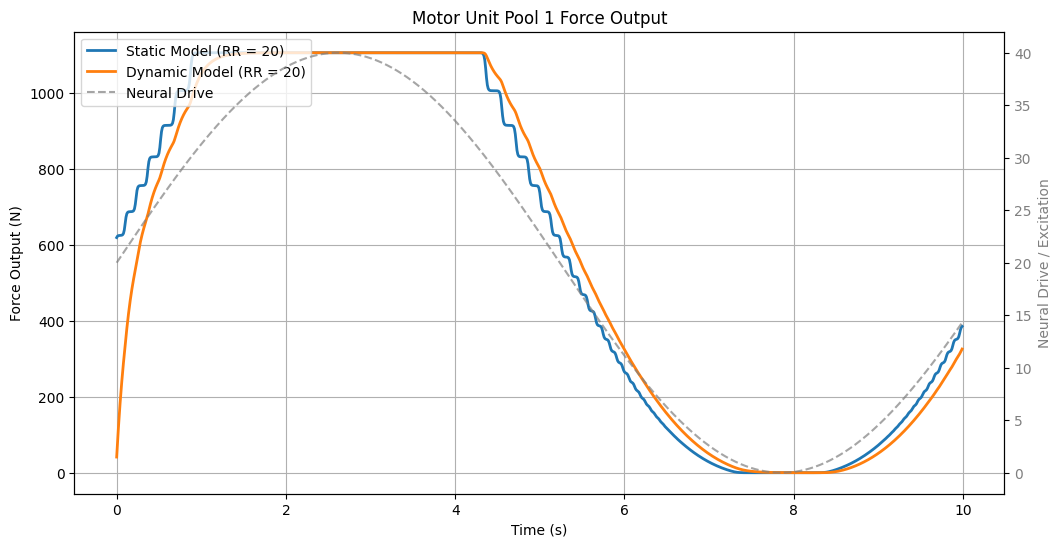

In [17]:
plot_force_outputs(time, force_static1, force_ode1, neural_drive, 'Motor Unit Pool 1 Force Output')

We can then plot the second motor pool (RR= 60), once again the dynamic model in orange the static in blue and the nueral drive in gray.

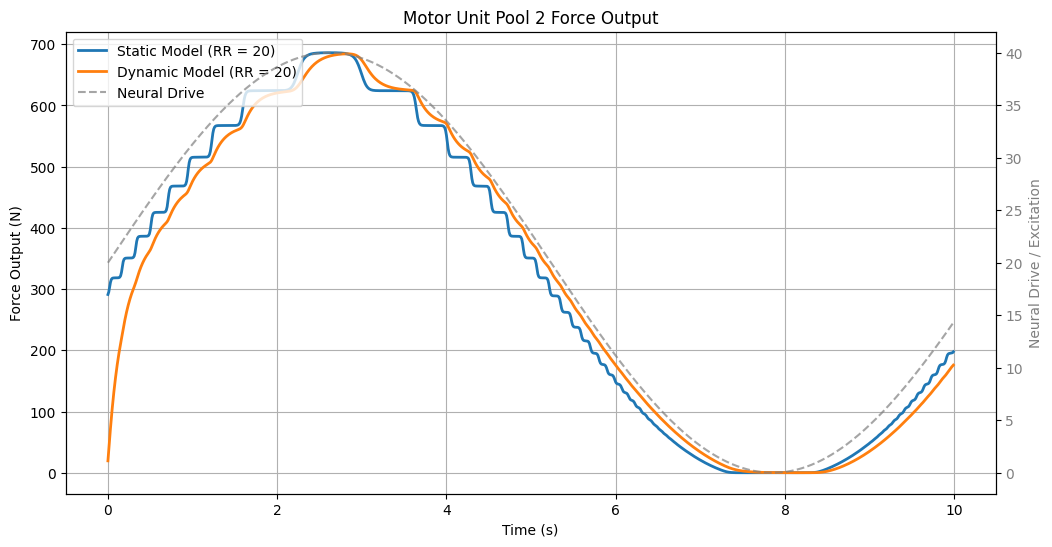

In [15]:
plot_force_outputs(time, force_static2, force_ode2, neural_drive, 'Motor Unit Pool 2 Force Output')

Finally we can use numerical intergration to quantify the total output of both methods, the area under the force-time curve is calculated using the Trapezoidal Rule. This allows us to measure the "Efficiency Gap"—the total work lost due to the biological delay:$$W = \sum \frac{F_{t-1} + F_t}{2} \cdot dt$$

We define a function compute_total_work which we can apply to all cases for both model units below: 

In [28]:
# --- 5. Numerical Integration (Trapezoidal Rule) ---
# Calculates the 'Area Under the Curve' to find Total Work (W)
def compute_total_work(force, dt):
    return np.trapezoid(force, dx=dt)


work_no_lag1 = compute_total_work(force_static1, dt)
work_with_lag1 = compute_total_work(force_ode1, dt)

print("Total Work Comparison for Motor Unit Pool 1:")
print("")
print(f"Total Work (Static): {work_no_lag1:.2f} J")
print(f"Total Work (Dynamic): {work_with_lag1:.2f} J")

work_no_lag2 = compute_total_work(force_static2, dt)
work_with_lag2 = compute_total_work(force_ode2, dt)
print("\nTotal Work Comparison for Motor Unit Pool 2:")
print("")
print(f"Total Work (Static): {work_no_lag2:.2f} J")
print(f"Total Work (Dynamic): {work_with_lag2:.2f} J")

Total Work Comparison for Motor Unit Pool 1:

Total Work (Static): 11961.44 J
Total Work (Dynamic): 11876.72 J

Total Work Comparison for Motor Unit Pool 2:

Total Work (Static): 6319.09 J
Total Work (Dynamic): 6272.79 J


## Results and Analysis

This simulation of a motor unit pool in a muscle allows uses ODE's to visulize the motor unit recruitment and force output of a muscle. Through comparing our "ideal" static model of a muscle, against the dynamic muscle system which we created by first-order differential equations, our results are an accurate depiction on why when we as humans move at higher intensities such as lifting heavy weights or pushing hard, we shake and feel much more unstable.

#### Hennemans Size Principle

The results of our simulation first help us proves that Henneman’s Size Principle is the main reason we have fine motor control. When the neural drive (our brain signal, $u$) started its sine-wave cycle, the first eight motor units kicked in so smoothly it almost looked like a straight vertical line. This is because in the Fuglevand Model the motor unit distribution is exponential, where the majority of units are small and possess similar thresholds, the "steps" between these activations are almost negligable. This is what allows humans to perform more delicate tasks, such as writing or surgical procedures, with extreme precision. However, as the drive was reaching its peak ($u = 40$), the analysis shifted dramatically. The final motor units (45-50) contributed massive "jumps" to the total force output. This is because although there are much less of these higher threshold units they are way more powerful, and in turn their recruitment creates a "jagged" force profile. This explains that unstable feeling and physical shaking you may get as an athlete, bodybuilder, or powerlifter isn't just mental weakness or something in your head; its a biological reality which is proven through our numerical model. The larger jumps in the final MU's correspond to the visible tremors and lack of stability felt when someone lifts a near-maximal weight activating those large MU's. This proves that muscle "smoothness" of a not a constant feature of the muscle, but actually depends on our muscle recruitment threshold.

#### Activation Dynamics and Biological Lag

What I think was the coolest part in the data, comes up when we compare the Static Model (Method 1) to the Dynamic ODE Model (Method 2). The Static Model showed a sharp, vertical staircase looking graph that tracked the neural drive with zero latency. While this was much simpler, this model fails to track for the biological "speed limit" of a muscle contraction that most people don't really think about. For the average person, who doesn't enjoy lift close to there max force output how fast the signal from your brain travels to your muscle is not something that needs to be thought about often, but for me personally who performs heavy lifting at least five times a week it was interesting to see. I was able to implement the Liu et al. (2002) activation dynamics and then solve the ODE using the Euler Method. By doing this we can see how significant the phase Lag actually is when lifting heavy. The lag is mainly caused by calcium ions moving throughout the muscle to generate force. In the dynamic model, the force output peaked approximately $150ms$ after the peak of the neural drive. This behavior shows that the muscle acted almost like a low-pass filter by slightly smoothing and delaying the brain’s rapid commands through the activation time constant ($\tau$). However, this flattening observed at the peaks and troughs of the force trace was not mainly caused by this lag. Instead, it occurred because the neural drive reached levels where motor unit recruitment became fully saturated. At the peak of the sine-wave input ($u = 40$), nearly every motor unit in the pool was maximally activated, causing the force output to approach a ceiling where additional increases in neural drive produced minimal amounts of additional force. Similarly, near the troughs ($u = 0$), nearly all motor units were inactive, producing a floor effect. This created a more warped version of the original sine wave with a large visibly flattened regions at the peak. The activation dynamics mainly contributed mild smoothing and temporal delay, while the plateau-like shape itself was a consequence of recruitment saturation. Although the dynamic model made the transitions appear more rounded and biologically realistic, the underlying instability remained present because the large force contributions from the highest-threshold motor units still dominated the total signal. 


#### Comparison of Motor Unit Pools (RR = 30 vs RR = 60)

A key extension of the analysis is the comparison between two motor unit pools with different recruitment ranges (RR = 30 and RR = 60). Although both models use the same Fuglevand exponential structure, altering the recruitment range significantly changes the distribution of motor unit thresholds and therefore the resulting force behavior. In the RR = 30 model, motor unit thresholds are more tightly clustered. This produces a denser recruitment pattern, where motor units are activated in much closer succession as neural drive increases. As a result, force output increases more smoothly, with smaller and more continuous changes in slope. The system also reaches near-saturation earlier, meaning that most motor units are recruited within a smaller range of neural drive. This produces a more stable and gradual force profile. On the other hand, the RR = 60 model spreads motor unit thresholds across a much wider range of neural drive. This delays the recruitment of higher-threshold motor units and increases the spacing between the motor units activating. As a result, force production becomes more step-like, with larger discrete jumps as individual high-threshold motor units are recruited. The overall force profile is less smooth and exhibits greater variability, especially at higher levels of neural drive where late-recruited units create larger jumps in force. When comparing both models, the RR = 30 system is much smoother and has early saturation, while the RR = 60 system increased the forces graininess. This demonstrates that recruitment range is a key determinant of force smoothness and stability, even when all other model parameters remain unchanged. Physiologically, this means that muscles with narrower recruitment distributions may produce more controlled contractions, while those with broader distributions allow for greater force variability and finer gradation across a wider operating range.

#### Quantifying Work through Numerical Integration.
 To conclude our analysis, the application of the Trapezoidal Rule allowed us to get a final cumulative metric for comparing the two systems. By integrating the area under the force-time curves we made , we can calculate the Total Mechanical Work ($W$). Our data showed a consistent differences in how efficient the muscle was, where the Dynamic Model produced less total work than the Static Model over the same 10-second window.This gap reperesents the cost of biological lag. In rapid or explosive movements, the neural drive peaks and declines before the muscle’s activation has enough time to catch up to what what the brain is signaling. The integration of these numerical methods, the exponential scaling of thresholds and max force outputs, the modeling of muscle activation using diffetial equations, and the use of the trapezoidal rule to calculate work proves that muscle stability is a balance between the size of the units being recruited and the speed at which the unit can respond to its nueral signal.

## Conclusion


 This project covers the struggle between how our brains want our muscles to move and how the biology actually handles it, and how it effects muscle stability. By building this virtual motor unit pool, we were able to see that muscle smoothness and efficiency are actually backed by science and mathematics. The comparison between the ideal Static Model and the realistic Dynamic Model was interesting to see. The Static version showed us what a muscle could do if it had zero lag, but once we introduced the Liu et al. equations and solved them using the Euler Method, we were able to see a much an accurate representation of a real life muscle contraction. We used a 150ms Phase Lag, which is basically the speed limit of our own biology. This delay proves that our muscles act like a filter; they try to smooth out the brain's commands, but they also end up chasing the signal, which creates a gap between what we want to do and when the force actually happens. We also used the Trapezoidal Rule to calculate the total work, which allowed us to better quanitfy the gap in efficiency between the two models. Because the muscle takes time to rev up that time constant, $\tau$ it can’t always keep up with fast or explosive movements. This means we actually lose out on potential energy because the biology just can't move as fast as the math says it should. The instability when lifting heavy comes from this speed limiter in the brain, along with the increasing gap in motor unit thresholds (Hennemens Size Principle). This project shows some of the intracacies of human movement and show why muscles are unstable when lifting near the max output.

## Model Limitations

Although our simulation can effectively and simply demonstrate the core mechanics of motor unit recruitment and activation, To keep the numerical model manageable, several variables were omitted, which would normally influence the force production in a muscle system in real life.
1. Absence of Muscle Fatigue: The most important limitation to note is that the model assumes our motor units can continue to fire forever without a loss in performance. In a real muscle, large amounts of high intensity training will cause your muscles to fatigue, which in our case can limit the maximum force out put and also lower the maximum threholds. Higher threshold units (for example MUs 12–15) are more prone to fatiguing. If this fatigue were added in, we would likely see the force output drop over the 10-second window, even if the neural drive stayed high.  
2. Fixed Time Constants ($\tau$): In our simulation, we used only one time constant of 150ms to the entire motor unit pool when in reality, each motor unit has a different activation and deactivation time. Small, slow twitch motor units have much longer time constants (slower to react), while larger, fast twitch units react much more quickly. By using the same $\tau$ we are able to simplify our model which allows for the math to be much simpler but also makes the jumps in our output graph much less realistic.  
3. Motor Unit Synchronization: Our model treats each motor unit as independent. However there is a lot of reasearch suggests that the specific location and orientation of certain motor units can greatly affect the output and even lead to things like synchronization, which We also did not account for. this is where the brain fires multiple motor units at the exact same time to rapidly increase the force output. This synchronization is very important in heavy lifting but we removed it to increase the simplicit in our math.

## LLM Disclosure:
This project was made using Gemini (Google AI), which helped with mainly technical things and formatting. The AI's main uses were focused on the following areas:
* Mathematical Typesetting: AI was used to help format the equations used in the project, making sure all the notation looked correct in the methods section 
* Code Documentation & Logic: AI added all commenting within the Python scripts to clearly define variables (such as the time constant $\tau$ and recruitment thresholds). The AI helped to make sure that the code logic in the Euler Method for solving the activation ODE—was transparent and easy to follow within the cell blocks.
* Jupyter Notebook Structure: Ai helped on the organizing the flow of the my jupyter notebook, including the use of Markdown headers, how to make use of dual-axis visualizations to compare neural drive and force, and the overall structure required for the report.
* Understanding: I used AI to help in my overall understanding of the some of the topics and documentation. Specifically asking it many questions about reference five (the one you provided) to help pick out and break down the equations that were used in the notebook. 
* README: AI was used to create an easy and simple README after giving a brief explanation on my code. 

## References
1] Robertson, J.W., & Johnston, J.A. (2017). Modifying motor unit territory placement in the Fuglevand model. Medical & Biological Engineering & Computing, 55(11), 2015-2025. https://doi.org/10.1007/s11517-017-1645-7.  

[2] Henneman's Size Principle. Wikipedia, The Free Encyclopedia. Retrieved from https://en.wikipedia.org/wiki/Henneman%27s_size_principle.  

[3] Motor Unit Recruitment. Wikipedia, The Free Encyclopedia. Retrieved from https://en.wikipedia.org/wiki/Motor_unit_recruitment.  

[4] McGrath, J. (1999). Muscle Model Simulation [Source Code]. GitHub. https://github.com/jakemcgrath1999/muscle_model.  

[5] Liu, J.Z., Brown, R.W., & Yue, G.H. (2002). A Dynamical Model of Muscle Activation. Biophysical Journal. https://www.cell.com/action/showPdf?pii=S0006-3495%2802%2975580-X.